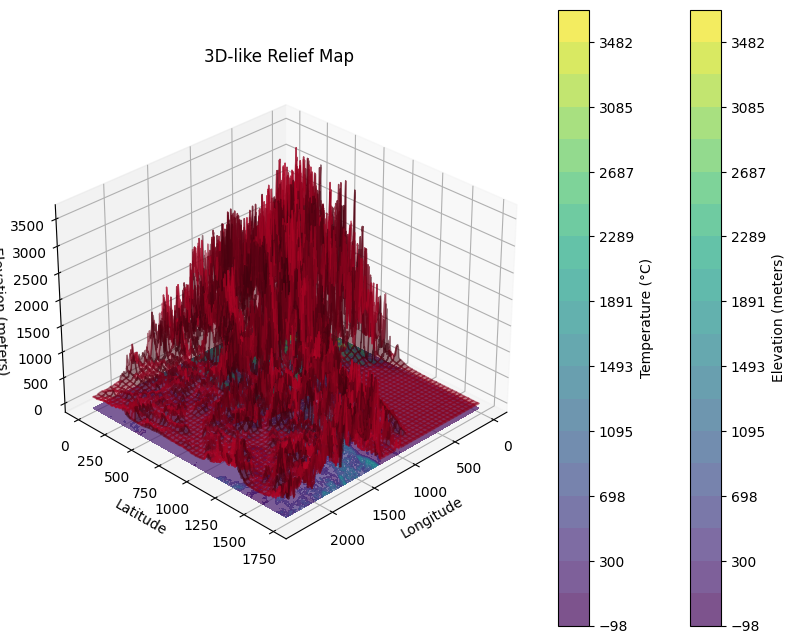

In [2]:
from osgeo import gdal
import matplotlib.pyplot as plt
import numpy as np

# Load the SRTM data
dataset = gdal.Open(r'../data/shading/srtm_slo_250.tif')
band1 = dataset.GetRasterBand(1)
elevation = band1.ReadAsArray()

# Create a Matplotlib figure and axis
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': '3d'})

# Customize the appearance of the SRTM background
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Elevation (meters)')
ax.set_title('3D-like Relief Map')

# Define contour levels and colormap for the overlay
contour_levels = np.linspace(elevation.min(), elevation.max(), 20)
contour_colormap = plt.get_cmap('viridis')

# Create color contours on top of the SRTM background
x = np.arange(0, elevation.shape[1])
y = np.arange(0, elevation.shape[0])
X, Y = np.meshgrid(x, y)
contour = ax.contourf(X, Y, elevation, levels=contour_levels, cmap=contour_colormap, zdir='z', offset=elevation.min(), alpha=0.7)

# Add a colorbar for the contour levels
cbar = plt.colorbar(contour, ax=ax, label='Elevation (meters)')

# Set the elevation and azimuth for the 3D-like effect
ax.elev = 30  # Adjust the elevation angle as needed
ax.azim = 45  # Adjust the azimuth angle as needed

# Generate random temperature data (replace this with your actual temperature data)
temperature_data = np.random.uniform(10, 30, elevation.shape)

# Overlay the temperature data on top of the relief map
temperature_colormap = plt.get_cmap('coolwarm')  # You can choose a different colormap
ax.plot_surface(X, Y, elevation, facecolors=temperature_colormap(temperature_data), alpha=0.5)

# Add a colorbar for the temperature data
cbar_temperature = plt.colorbar(contour, ax=ax, label='Temperature (°C)')

# Save or display the resulting 3D-like map with temperature overlay
plt.savefig('3DReliefMapWithTemperature.png')
plt.show()


1
